# Task 6 — Cross-task synthesis (no new training)
Collects the evidence of Tasks 1–5 along the manual's five synthesis axes: preference strength vs policy drift; offline vs online feedback; optimisation bias; safety calibration; reward-source design. Every number is read from the saved results; the report tables (`report/tables/*.csv|tex`) are rebuilt by `python -m common.visualize_all`, and auto-selected qualitative candidates are in `report/qualitative_candidates.md`.

Cross-method comparisons are observational: DPO is evaluated on prompts from the UltraFeedback held-out pairs, PPO/GRPO on the held-out RL prompt pool with different generation caps, and the methods differ in more than one training detail.


In [1]:
%matplotlib inline
import os, sys, json, re
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "configs").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, yaml
from IPython.display import display, Markdown, HTML, Image
from common.nb_helpers import (style, load, jl, exists, pending, run, side_by_side, ci_text,
                               bootstrap_mean_diff, smooth, full_windows, PALETTE, SEQ, RES, FIG)
from common.metrics import length_stats, wilson_interval
from common.data import load_yaml
style()
print("repo root:", ROOT)

repo root: C:\Users\moize\OneDrive - Higher Education Commission\Desktop\Academics\ATML\PA2


## Run this step (optional)
The results below come from the Kaggle run of the script pipeline (`kaggle_runner.ipynb`). Set `FORCE_RUN = True`
to re-run the step's scripts from here (needs a CUDA GPU and the downloaded course assets).


In [2]:
FORCE_RUN = False
if FORCE_RUN:
    run('python -m common.visualize_all')
    run('python -m scripts.extract_qualitative')
else:
    print('Using saved results under results/ (FORCE_RUN = False).')

Using saved results under results/ (FORCE_RUN = False).


## 1. Drift, reward change and length change for every trained condition

In [3]:
rows = []
def add(method, cond, e, base):
    rows.append({"method": method, "condition": cond, "KL token": e["kl_token_mean"], "KL seq": e["kl_sequence_mean"],
                 "Δ RM vs start": e["mean_reward"] - base["mean_reward"], "RM s.e.m.": e["sem_reward"],
                 "Δ length vs start": e["length_tokens"]["mean"] - base["length_tokens"]["mean"], "entropy": e["entropy_exact"]})
sft = load("task1_dpo/dpo_eval_sft_reference.json")
for cond, f in [("standard (1 epoch)", "standard"), ("β=0.03", "ablation_beta_0_03"), ("β=0.10", "ablation_beta_0_10"), ("β=0.30", "ablation_beta_0_30"), ("length-balanced", "length_balanced")]:
    add("DPO", cond, load(f"task1_dpo/dpo_eval_{f}.json"), sft)
mid = load("task2_ppo/ppo_eval_midpoint.json")
for f in ["standard", "fork_eps0_05_kl0_10", "fork_eps0_20_kl0_10", "fork_eps0_50_kl0_10", "fork_eps0_20_kl0_00", "fork_eps0_20_kl0_20"]:
    if exists(f"task2_ppo/ppo_eval_{f}.json"): add("PPO", f, load(f"task2_ppo/ppo_eval_{f}.json"), mid)
gmid = load("task3_grpo/grpo_eval_midpoint.json")
for f in ["standard", "fork_norm_grpo", "fork_norm_dr_grpo"]:
    add("GRPO", f, load(f"task3_grpo/grpo_eval_{f}.json"), gmid)
D = pd.DataFrame(rows); D.set_index(["method", "condition"]).round(4)

KL token  KL seq  Δ RM vs start  RM s.e.m.  Δ length vs start  entropy
method condition                                                                                  
DPO    standard (1 epoch)     0.0005  0.0819         0.0163     0.0852            -3.7500   0.9573
       β=0.03                -0.0000 -0.0073        -0.0008     0.0870            -1.5950   0.9474
       β=0.10                -0.0001 -0.0142         0.0478     0.0856            -2.1600   0.9482
       β=0.30                -0.0001 -0.0226        -0.0225     0.0861            -2.4950   0.9448
       length-balanced        0.0028  0.4516         0.0874     0.0850             0.1850   0.9498
PPO    standard              -0.0000 -0.0100        -0.0958     0.1665             7.4844   0.9836
       fork_eps0_05_kl0_10    0.0000  0.0083         0.0513     0.1628             4.6562   0.9969
       fork_eps0_20_kl0_10   -0.0000 -0.0077         0.1326     0.1553            14.9688   0.9795
       fork_eps0_50_kl0_10   -0.0000 -0.0077         0.1326     0.1553            14.9688   0.9795
GRPO   standard               0.0001  0.0183         0.0229     0.1496             5.3438   0.9640
       fork_norm_grpo         0.0001  0.0234        -0.0022     0.1464             2.9062   0.9704
       fork_norm_dr_grpo      0.0001  0.0297        -0.0083     0.1497             1.4375   0.9856

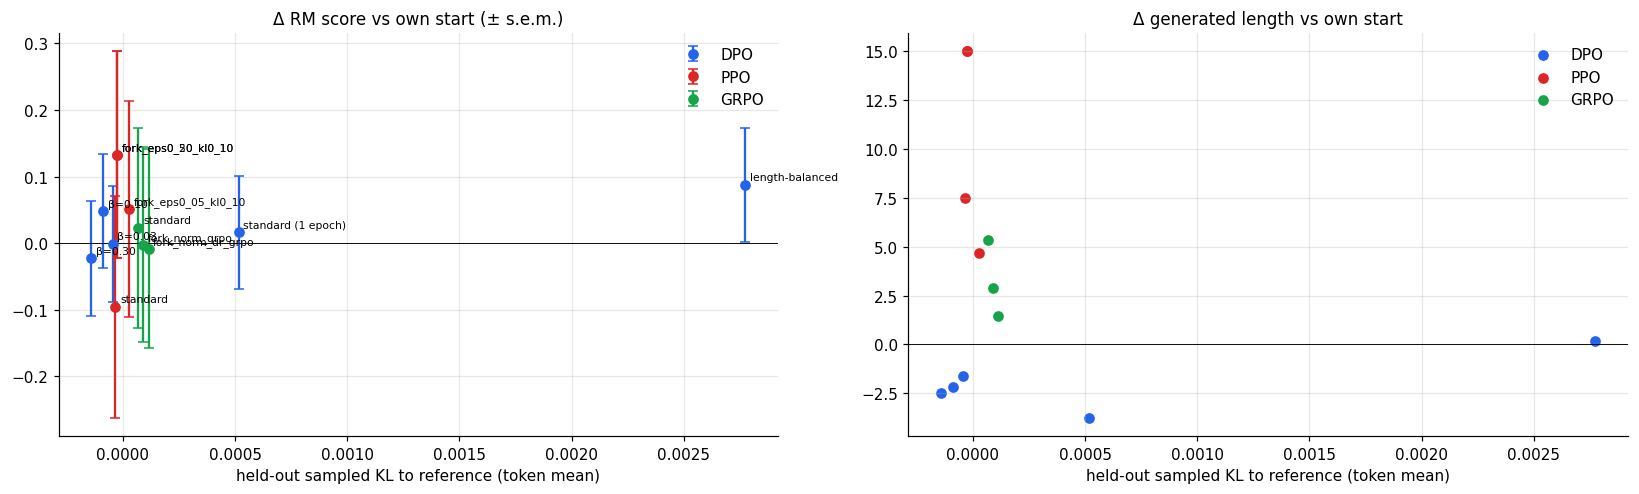

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4.6))
for m, c in [("DPO", "#2563EB"), ("PPO", "#DC2626"), ("GRPO", "#16A34A")]:
    s = D[D.method == m]
    ax[0].errorbar(s["KL token"], s["Δ RM vs start"], yerr=s["RM s.e.m."], fmt="o", color=c, label=m, capsize=3)
    ax[1].scatter(s["KL token"], s["Δ length vs start"], color=c, label=m)
    for r in s.itertuples():
        ax[0].annotate(r.condition, (r[3], r[5]), fontsize=7, xytext=(3, 3), textcoords="offset points")
for a, t in zip(ax, ["Δ RM score vs own start (± s.e.m.)", "Δ generated length vs own start"]):
    a.axhline(0, color="k", lw=0.6); a.set_xlabel("held-out sampled KL to reference (token mean)"); a.set_title(t); a.legend()
fig.tight_layout(); plt.show()

## 2. Offline vs online: what the training signal saw

In [5]:
pp = load("task1_dpo/dpo_eval_standard.json")["per_pair"]
ppo = pd.DataFrame(jl("task2_ppo/ppo_train_standard.jsonl")); grpo = pd.DataFrame(jl("task3_grpo/grpo_train_standard.jsonl"))
pd.DataFrame({
    "DPO (standard)": {"training samples": "1443 fixed pairs (offline)", "updates": 91, "drift measure": f"KL {load('task1_dpo/dpo_eval_standard.json')['kl_token_mean']:.5f}",
                       "signal on dataset responses": f"mean log-ratio chosen {np.mean([p['logratio_chosen'] for p in pp]):+.3f}, rejected {np.mean([p['logratio_rejected'] for p in pp]):+.3f}"},
    "PPO (standard)": {"training samples": f"{len(ppo)} on-policy rollouts", "updates": len(ppo), "drift measure": f"KL {load('task2_ppo/ppo_eval_standard.json')['kl_token_mean']:.5f}",
                       "signal on dataset responses": "— (online reward)"},
    "GRPO (standard)": {"training samples": f"{4 * len(grpo)} on-policy completions", "updates": len(grpo), "drift measure": f"KL {load('task3_grpo/grpo_eval_standard.json')['kl_token_mean']:.5f}",
                        "signal on dataset responses": "— (online group reward)"}}).T

,training samples,updates,drift measure,signal on dataset responses
DPO (standard),1443 fixed pairs (offline),91,KL 0.00052,"mean log-ratio chosen -0.534, rejected -0.957"
PPO (standard),20 on-policy rollouts,20,KL -0.00003,— (online reward)
GRPO (standard),80 on-policy completions,20,KL 0.00007,— (online group reward)


## 3. Report tables

In [6]:
for t in ["t1_dpo_summary", "t2_ppo_heldout", "t3_grpo_heldout", "t4_safety", "t5_math", "t5_judge_outputs", "t_compute"]:
    f = ROOT / "report" / "tables" / f"{t}.csv"
    if f.exists():
        display(Markdown(f"**{t}**")); display(pd.read_csv(f))

**t1_dpo_summary**

,condition,β,budget,held-out DPO loss,pref. acc.,KL tok,KL seq,RM,len (tok),IQR,EOS
0,SFT (no adapter),—,—,NaN,NaN,0.0000,0.00,1.282 ± 0.086,162.6 ± 102.6,206.0,0.55
1,Standard DPO,0.10,"1 epoch, all kept train pairs",0.675,0.637,0.0005,0.08,1.299 ± 0.085,158.8 ± 102.1,207.0,0.57
2,Short fork β=0.03,0.03,"600 pairs, 1 pass",0.691,0.606,-0.0000,-0.01,1.282 ± 0.087,161.0 ± 103.2,208.0,0.56
3,Short fork β=0.1,0.1,"600 pairs, 1 pass",0.687,0.637,-0.0001,-0.01,1.330 ± 0.086,160.4 ± 102.3,206.0,0.56
4,Short fork β=0.3,0.3,"600 pairs, 1 pass",0.677,0.630,-0.0001,-0.02,1.260 ± 0.086,160.1 ± 103.0,208.0,0.55


**t2_ppo_heldout**

,policy,setting,RM,KL tok,entropy,len,EOS
0,SFT (no adapter),—,1.562 ± 0.173,0.0,0.981,292.4 ± 257.7,0.94
1,PPO midpoint (start),—,1.727 ± 0.169,0.0,0.942,290.4 ± 260.8,0.94
2,Standard PPO (20 updates),"ε=0.20, β_KL=0.10",1.631 ± 0.166,-0.0,0.984,297.8 ± 274.3,0.94


**t3_grpo_heldout**

...

,policy,GSM acc,GSM format,GSM len,SVAMP acc,SVAMP len,acc drop
0,SFT,0.283,0.35,274 ± 85,0.44,164 ± 72,-0.157
1,RLVR,0.287,0.36,276 ± 86,0.46,164 ± 73,-0.173
2,RLAIF,0.287,0.36,275 ± 88,0.44,163 ± 71,-0.153
3,RLVR VS SFT,win 0.503,ties 286/unparsed 0,agree 0.08,win 0.515,NaN,-0.012
4,RLAIF VS SFT,win 0.495,ties 287/unparsed 0,agree 0.00,win 0.525,NaN,-0.030
5,RLVR VS RLAIF,win 0.507,ties 284/unparsed 0,agree 0.10,win 0.530,NaN,-0.023


**t5_judge_outputs**

,set,comparison,n,decisive A/B,explicit TIE,ambiguous (echo/unparsed)
0,gsm,rlaif_vs_sft,300,5,287,8
1,gsm,rlvr_vs_sft,300,6,286,8
2,gsm,rlvr_vs_rlaif,300,7,284,9
3,transfer,rlaif_vs_sft,100,0,79,21
4,transfer,rlvr_vs_sft,100,0,79,21
5,transfer,rlvr_vs_rlaif,100,0,80,20
6,diagnostics,reasoning_sensitivity,20,0,20,0
7,diagnostics,outcome_sensitivity,20,0,20,0
8,diagnostics,filler_susceptibility,20,1,15,4
9,diagnostics,distractor_robustness,20,6,14,0


**t_compute**

,run,wall-clock (min),peak VRAM (GB),generated tokens
0,DPO standard (1 epoch),20.0,7.11,— (offline)
1,PPO standard (20 updates),6.0,7.01,6299
2,GRPO standard (20 updates),7.6,5.83,24063


## 4. Safety calibration vs reward

In [7]:
S = load("task4_safety/safety_evaluation_results.json")
pd.DataFrame({p.upper(): {"safe answer": S[p]["metrics"]["safe_answer"]["rate"], "any refusal on SAFE": S[p]["metrics"]["safe_any_refusal"]["rate"],
                          "unsafe compliance": S[p]["metrics"]["unsafe_compliance"]["rate"], "justified refusal": S[p]["metrics"]["justified_refusal"]["rate"]}
              for p in ["sft", "dpo", "ppo", "grpo"]}).T.round(3)

,safe answer,any refusal on SAFE,unsafe compliance,justified refusal
SFT,0.580,0.408,0.0,0.885
DPO,0.564,0.424,0.0,0.870
PPO,0.572,0.420,0.0,0.875
GRPO,0.568,0.420,0.0,0.875


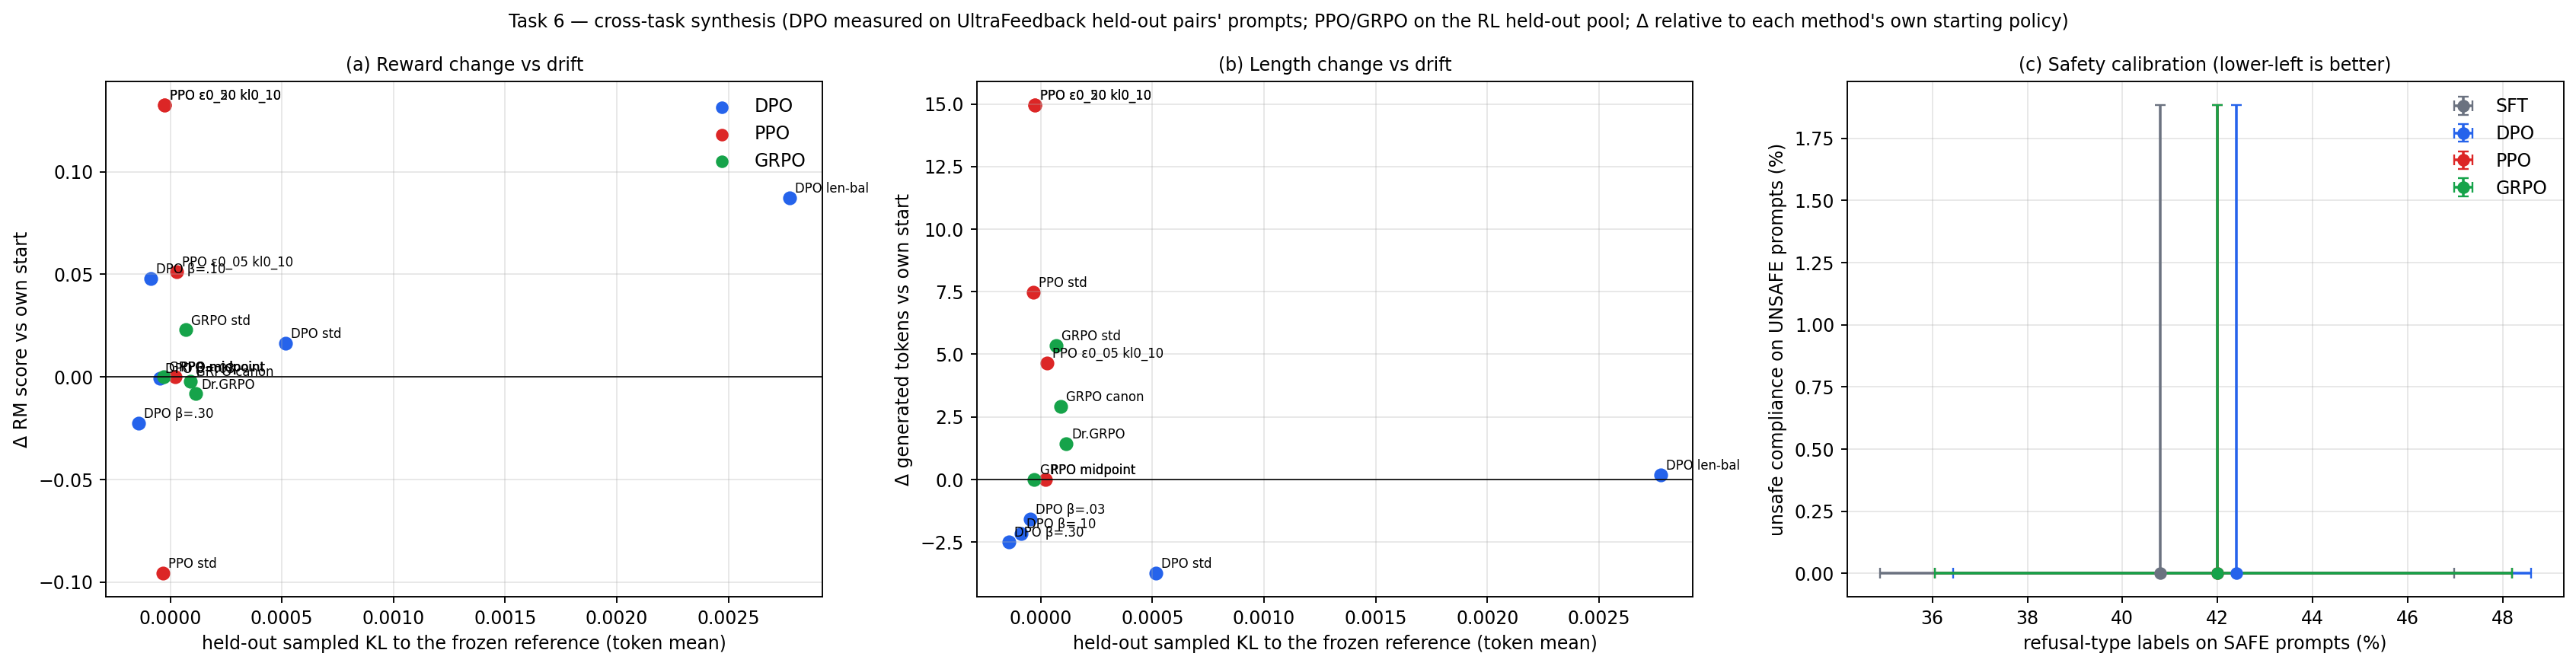

In [8]:
display(Image(filename=str(FIG / "task6_cross_task_synthesis.png"), width=1100))

## 5. Qualitative candidates (auto-selected; read the full texts before using any)

In [9]:
q = (ROOT / "report" / "qualitative_candidates.md").read_text(encoding="utf-8")
display(Markdown(q[:12000] + ("\n\n… (truncated; full file: report/qualitative_candidates.md)" if len(q) > 12000 else "")))

# Qualitative candidates (auto-selected; verify by reading the full texts)


## Task 1 — DPO

#### (i) preference/reward vs quality
_source: `task1_dpo/dpo_eval_sft_reference.json` vs `task1_dpo/dpo_eval_standard.json` (same prompt, same sampling seed)_

**RM increased while the response grew (DPO vs SFT)**

- `5a9a0bda09` RM -0.49 → +1.72, len 77 → 142 tok, EOS True→True
  - prompt: John keats poem called bright star
  - SFT: The poem you're referring to is "Bright Star" by John Keats. It's one of the most famous poems from his collection "Endymion." The poem expresses deep love and longing for someone named Lorna, who appears as an object in the sky that looks like a bright star. It explores themes of mortality, beauty, and the ephemeral nature of life.
  - DPO: The poem you're referring to is "Bright Star" by John Keats. This sonnet was written in 1819 and is considered one of the most famous poems from Keats' short-lived career as an English Romantic poet. The poem explores themes of love, longing, and the passage of time. The speaker imagines seeing a distant object that he believes to be a bright star, …
- `43edbcf9c3` RM -0.22 → +1.29, len 65 → 170 tok, EOS True→True
  - prompt: List a kind of lilies that grows under the sea.
  - SFT: Hydrocoral lilies (Hydractinia spp.) grow on coral reefs in shallow waters around the world and can be found growing directly on the ocean floor as well. They do not actually produce flowers but instead release spores into the water column which may float away from their habitat to form new colonies elsewhere.
  - DPO: Hydrocoral lilies (also known as deep-sea orchids or hydrozoan orchids) are fascinating organisms that grow in marine environments. They belong to the order Actinaria and have a unique way of photosynthesis using their symbiotic algae. These species typically live in very dark and nutrient-poor waters at depths ranging from 100 meters down to about …
- `9d9d43d9e7` RM -0.92 → +1.49, len 256 → 256 tok, EOS False→False
  - prompt: How can I use Ruby to store and retrieve data from an SQL database in this code? Here is the sample code: sentence = "I love singing in the rain." words = sentence.split(" ") words[0] = "You" newSente …
  - SFT: To modify your Ruby code to connect to an SQL database, you need to add the necessary gems for connecting to PostgreSQL, define the table structure and columns, and write a script that inserts and retrieves records from the table. Here's an example of how you could modify your code to achieve this: ```ruby require 'pg' # Connect to the database con …
  - DPO: To modify your Ruby code to connect to an SQL database, you need to add the necessary gems for connecting to PostgreSQL (PG gem), and then write the appropriate code to perform the insertion and retrieval of data. Here's how you can modify the code: ```ruby require 'pg' # Connect to the database conn = PG.connect(dbname: 'mydb', user: 'myuser', pas …
- `651e4c1d0b` RM -1.65 → -0.11, len 23 → 35 tok, EOS True→True
  - prompt: Hi GPT! Today we're going to be creating our own language. Do not improvise unless I explicitly tell you to improvise, and remember all of the vocabulary and grammar that we define together. Are you r …
  - SFT: Yes, I am ready. Let's get started. What would you like to create your own language for?
  - DPO: Yes, I am ready. Let's get started on defining our new language together. Please provide me with some examples or ideas for words and phrases in your desired language.
- `387350f4ed` RM +1.49 → +3.30, len 203 → 245 tok, EOS True→True
  - prompt: Can you solve this puzzle related to restaurant management systems? Here are three clues to help you out: 1. This framework is commonly used for building web applications and offers features such as S …
  - SFT: Based on the clues provided, these could be referring to: * Framework: Spring Boot * Database Access Library: Hibernate ORM (Java Persistence API) * Integration Framework: Apache Camel Spring Boot is a popular lightweight framework that simplifies development of enterprise-grade web applications using the Spring Framework. It abstracts away many bo …
  - DPO: Based on the clues provided, we can deduce that the three Java technologies and frameworks being referred to are: 1. **Spring Framework**: The first clue mentions Spring Data, Spring Security, and Spring MVC, which are all components of the Spring Framework. Spring is known for its extensive feature set, including support for various data access me …

**Largest RM drops (DPO vs SFT)**

- `3af1bdb3f9` RM +1.84 → -1.27; len 256 → 256
  - SFT: Sure! Here's an example email with a personalized hook and three specific ways it can be improved: --- **Personalized Hook:** Hi [Name], I hope you're doing well! I noticed that when we last spoke, you were looking to streamline your 1:1 meetings. Recently, I've been editing some [about their current method of setting agendas]. It was really eye-op …
  - DPO: Sure! Here's an example email based on the provided structure: --- **Subject:** Enhancing Your Team Meetings with Fellow – A Comprehensive Review Dear [Recipient’s Name], I hope you're doing well! I wanted to share some exciting news about how Fellow is transforming our team meetings. Did you know that after implementing Fellow, we've been able to  …
- `729ee2a5c7` RM +1.89 → -0.92; len 222 → 25
  - SFT: To determine Jeff's motivation for wanting to use his own car after watching the race movie, let's analyze the situation: 1. **Context**: Jeff was watching a car racing movie. 2. **Sentence**: Afterwards, he felt like using his own car for races. 3. **Character**: Jeff **Analysis**: - Watching a car racing movie typically leads to feelings of excit …
  - DPO: To feel adventurous and test his skills on the open road, as well as satisfy his love for fast-paced thrill rides.
- `1335a25cc6` RM +1.35 → -0.47; len 256 → 256
  - SFT: Yes, it is possible to export specific data from Shopify Orders into various formats such as CSV (Comma-Separated Values), JSON, Excel, or PDF. Here’s how you can do it: ### 1. **CSV Export** - **Step-by-Step:** 1. Log into your Shopify admin panel. 2. Go to `Orders` > `All Orders`. 3. Click on the order that you want to export. 4. Scroll down to t …
  - DPO: Yes, it is possible to export specific data from Shopify Orders into various formats such as CSV (Comma-Separated Values), JSON, Excel, or PDF. Here’s how you can do it: ### 1. **CSV Export** - **Step-by-Step:** 1. Log into your Shopify admin panel. 2. Go to `Online Store` > `Orders`. 3. Click on the order that you want to export. 4. Scroll down an …

**Highest-RM response that never terminated (DPO)**: RM +3.30, 256 tok — The success of a Chief Underwriter (CU) in an insurance company can be measured and optimized through various key performance indicators (KPIs). These KPIs help gauge the effectiveness of their decisions and strategies in managing risk, pricing policies, and overall financial outcomes. Here are some common quantitative metrics that CU's often aim to optimize: 1. **Claim Costs**: The amount paid out in claims per insured unit or policy. A lower claim cost indicates more efficient risk management. …

#### (ii) Word-limit prompts (greedy)

- **Explain why regularization can improve generalization in at most 40 words.** (limit 40)
  - sft: 34 words ✓ — Regularization helps prevent overfitting by adding a penalty term to the loss function that discourages large weights, thus simplifying the model and reducing its complexity. This makes the model generalize better to uns …
  - standard: 34 words ✓ — Regularization helps prevent overfitting by adding a penalty term to the loss function that discourages large weights, thus simplifying the model and reducing its complexity. This makes the model generalize better to uns …
  - length_balanced: 34 words ✓ — Regularization helps prevent overfitting by adding a penalty term to the loss function that discourages large weights, thus simplifying the model and reducing its complexity. This makes the model generalize better to uns …
- **Define overfitting in no more than 25 words.** (limit 25)
  - sft: 28 words ✗ — Overfitting occurs when a model learns the training data too well, capturing noise and details specific to the training set that do not generalize to new, unseen data.
  - standard: 28 words ✗ — Overfitting occurs when a model learns the training data too well, capturing noise and details specific to the training set that do not generalize to new, unseen data.
  - length_balanced: 28 words ✗ — Overfitting occurs when a model learns the training data too well, capturing noise and details specific to the training set that do not generalize to new, unseen data.
- **Summarize the purpose of a validation set in at most 30 words.** (limit 30)
  - sft: 24 words ✓ — A validation set is used to evaluate the performance and accuracy of machine learning models during training, ensuring they generalize well to unseen data.
  - standard: 22 words ✓ — A validation set is used to tune hyperparameters and assess model performance during training without affecting the final evaluation on unseen data.
  - length_balanced: 22 words ✓ — A validation set is used to tune hyperparameters and assess model performance during training without affecting the final evaluation on unseen data.
- **Explain gradient descent in under 35 words.** (limit 35)
  - sft: 43 words ✗ — Gradient descent is an optimization algorithm used to minimize the cost function in machine learning models. It iteratively updates the model's parameters in the direction of steepest descent of the loss function, aiming …
  - standard: 55 words ✗ — Gradient descent is an optimization algorithm used to minimize the cost function in machine learning models. It iteratively updates the model's parameters in the direction of steepest descent based on the negative gradie …
  - length_balanced: 43 words ✗ — Gradient descent is an optimization algorithm used to minimize the cost function in machine learning models. It iteratively updates the model's parameters in the direction of steepest descent of the loss function, aiming …
- **Describe one advantage and one limitation of attention in at most 45 words.** (limit 45)
  - sft: 64 words ✗ — **Advantage:** Attention mechanisms allow models to focus on relevant information while ignoring irrelevant details during processing, enhancing the model's ability to understand complex tasks like language translation o …
  - standard: 47 words ✗ — Advantage: Attention allows models to focus on relevant information while ignoring irrelevant details, improving efficiency and accuracy. Limitation: It can lead to overfitting if not properly managed, as the model may b …
  - length_balanced: 64 words ✗ — **Advantage:** Attention mechanisms allow models to focus on relevant information while ignoring irrelevant details during processing, enhancing the model's ability to understand complex tasks like language translation o …
- **What is distribution shift? Answer in no more than 30 words.** (limit 30)
  - sft: 22 words ✓ — Distribution shift refers to changes in the data distribution between training and testing datasets, leading to performance degradation of machine learning models.
  - standard: 35 words ✗ — Distribution shift refers to changes in the data distribution between training and testing phases due to external factors such as new samples or different environments, leading to performance degradation of models traine …
  - length_balanced: 35 words ✗ — Distribution shift refers to changes in the data distribution between training and testing phases due to external factors such as new samples or different environments, leading to performance degradation of models traine …
- **Explain the role of a learning rate in at most 35 words.** (limit 35)
  - sft: 68 words ✗ — A learning rate is a hyperparameter that determines how much to adjust the model's weights during training based on the error between pr

… (truncated; full file: report/qualitative_candidates.md)